## Annual Climate Data for Death Valley, California

In [3]:
### import libraries
import earthpy ### manage local data
import holoviews as hv ### save interactive plots
import hvplot ### plotting
import hvplot.pandas ### make interactive plots
import pandas as pd ### work with tabular data in data frames

import matplotlib.pyplot as plt ### plotting tool
import seaborn as sns ### statistical plots

from sklearn.linear_model import LinearRegression ### fit an OLS linear regression

In [22]:
### Set weather station information 

### NCEI base url
ncei_base = 'https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries'

### Station Data URL: https://www.ncdc.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:USC00042319/detail

### Station Name
station_name = 'Death Valley National Park, CA'

### Station ID
station_id = 'USC00042319'
url_station = '&stations='+station_id

### Data Type
climate_data_type = 'TOBS' #,TMAX,TMIN
url_data_type = '&dataTypes='+climate_data_type

### Data Record Start Date
start_date = '1961-04-26'
url_start = '&startDate='+start_date

### Data Record End Date
end_date = '2025-12-31'
url_end = '&endDate='+end_date

ncei_url = ncei_base + url_data_type + url_station + url_start + url_end#+'&format=csv&units=standard' 

print(ncei_url)


https://www.ncei.noaa.gov/access/services/data/v1?dataset=daily-summaries&dataTypes=TOBS&stations=USC00042319&startDate=1961-04-26&endDate=2025-12-31


In [23]:
# Load climate data from NCEI
climate_df = pd.read_csv(ncei_url, 
    index_col = 'DATE', parse_dates = True, na_values = ['NaN']
    )

climate_df.head()

,STATION,TOBS
DATE,,
1961-04-26,USC00042319,306.0
1961-04-27,USC00042319,333.0
1961-04-28,USC00042319,356.0
1961-04-29,USC00042319,383.0
1961-04-30,USC00042319,378.0


In [24]:
climate_df.tail()

,STATION,TOBS
DATE,,
2025-12-27,USC00042319,NaN
2025-12-28,USC00042319,NaN
2025-12-29,USC00042319,NaN
2025-12-30,USC00042319,NaN
2025-12-31,USC00042319,NaN


<Axes: ylabel='Frequency'>

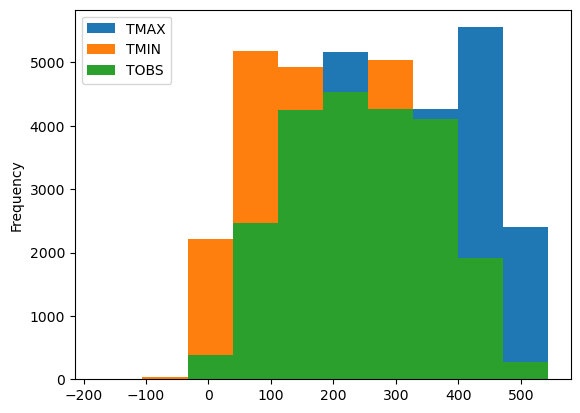

In [15]:
### Check distribution of missing temperature values (NaNs)
climate_df.plot.hist()

In [16]:
### Check data for null values
climate_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 23625 entries, 1961-04-26 to 2025-12-31
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   STATION  23625 non-null  object 
 1   TMAX     23587 non-null  float64
 2   TMIN     23560 non-null  float64
 3   TOBS     22195 non-null  float64
dtypes: float64(3), object(1)
memory usage: 922.9+ KB


In [17]:
### filter data frame to keep temperature observed (TOBS) to new data frame
temp_df = climate_df[['TOBS']]

### rename TOBS to TEMP
temp_df = temp_df.rename(columns = {'TOBS':'TEMP'})

### check updated data frame
temp_df

,TEMP
DATE,
1961-04-26,306.0
1961-04-27,333.0
1961-04-28,356.0
1961-04-29,383.0
1961-04-30,378.0
...,...
2025-12-27,NaN
2025-12-28,NaN
2025-12-29,NaN


In [12]:
temp_df_units = temp_df.rename(columns={
    'TEMP': 'temp_f'
})

temp_df_units

,temp_f
DATE,
1961-04-26,306.0
1961-04-27,333.0
1961-04-28,356.0
1961-04-29,383.0
1961-04-30,378.0
...,...
2025-12-27,NaN
2025-12-28,NaN
2025-12-29,NaN


In [ ]:
temp_df_units['temp_c'] = (temp_df_units['temp_f']-32) * (5/9)
temp_df_units

In [ ]:
### plot with modifications
temp_modified = temp_df_units.plot(
    y = 'temp_c',
    title = 'Daily temperature in Boulder Colorado',
    xlabel = 'Date',
    ylabel = 'Temperature ($^\circ$C)', 
    figsize = (12,6),
    fontsize = 14,
    color = 'green',
    #kind = 'bar'
    )

temp_modified.legend().remove()

In [ ]:
### find mean annual temp

ann_temp_df = (
    temp_df_units # data source
    .resample('YS') # resample frequency: annual/year start
    .mean() # aggregation method
)

ann_temp_df

In [ ]:
nn_temp_df.plot(
    y = 'temp_c',
    title = 'Mean annual temperature in Boulder, CO',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

In [ ]:
hvplot.extension("bokeh")

### plot the annual data interactively

ann_temp_plot = ann_temp_df.hvplot(
    y = 'temp_c',
    title = 'Mean annual temperature in Boulder, CO',
    xlabel = 'Year',
    ylabel = 'Temperature (deg C)'
)

ann_temp_plot

In [ ]:
hv.save(ann_temp_plot, 'annual_temp_plot_boulder.html')

In [ ]:
### verify data set does not have any NaN values
print(ann_temp_df.isna().sum())

### remove na data from data frame
ann_temp_df = ann_temp_df.dropna()

### verify data set does not have any NaN values
print(ann_temp_df.isna().sum())

### reduce data set to only celcius and date 
ann_temp_c_df = ann_temp_df[['temp_c']]

### filter data to avoid data gap and use only 1941-2023
clean_ann_temp_c_df = ann_temp_c_df.loc['1941':'2023']

clean_ann_temp_c_df.head()

### create two subset groups of years that show different slopes
### 1941-1980
early_ann_temp_df = clean_ann_temp_c_df.loc['1941':'1980']
### 1980-2023
late_ann_temp_df = clean_ann_temp_c_df.loc['1980':'2023']


In [ ]:
### fit an OLS Linear Regression to the data

### define independent variable
### reshape 'year' to be a 2D array for scikit-learn
x = clean_ann_temp_c_df.index.year.values.reshape(-1, 1)

### define dependent variable
y = clean_ann_temp_c_df.temp_c

### make linear regression model
model = LinearRegression()

### fit the model on the data
model.fit(x, y)

### calculate and print metrics
print(f'Slope: {model.coef_[0]} degrees per year')

In [ ]:
### plot data
ax = sns.regplot(
    x = clean_ann_temp_c_df.index.year, 
    y = clean_ann_temp_c_df.temp_c,

    line_kws={"color": "black"} # trendline color
)


### make labels
ax.set(
    title = 'Mean annual temperature in Boulder, CO (1941-2023)',
    xlabel = 'Year',
    ylabel = 'Temperature ($^\circ$C)'
)

### save your plot
plt.savefig('/workspaces/01-climate-fall-template/mean_ann_temp_w_trend_boulder.jpeg')

### plot it
plt.show()